### Imports & Data Loading

In [15]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

# Project root — same BASE as in 02_data_cleaning.ipynb
BASE = "/Users/alexia/Documents/CASA/Dissertation"

# Output folder for saved figures — created automatically if it does not exist
FIG_DIR = os.path.join(BASE, "06_outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Paths to the five cleaned CSVs in 05_processed/
CENSUS_CSV   = os.path.join(BASE, "05_processed", "census_london_clean.csv")
IMD_CSV      = os.path.join(BASE, "05_processed", "imd_london_clean.csv")
OSEV_CSV     = os.path.join(BASE, "05_processed", "osev_london_clean.csv")
EVSE_AVA_CSV = os.path.join(BASE, "05_processed", "evse_availability_clean.csv")
DEVICE_CSV   = os.path.join(BASE, "05_processed", "device_gla_clean.csv")

# Path to LSOA boundary file in 04_spatial/ — adjust filename if yours differs
LSOA_SHP = os.path.join(BASE, "03_data", "demand", "spatial", "LSOA_2021_EW_BGC_V5.shp")

# Load cleaned CSVs
census   = pd.read_csv(CENSUS_CSV)
imd      = pd.read_csv(IMD_CSV)
osev     = pd.read_csv(OSEV_CSV)
evse_ava = pd.read_csv(EVSE_AVA_CSV)
device   = pd.read_csv(DEVICE_CSV)

# Load LSOA boundary and reproject to British National Grid (EPSG:27700)
lsoa_gdf = gpd.read_file(LSOA_SHP).to_crs(epsg=27700)

# Standardise the LSOA code column name to 'lsoa_code' regardless of shapefile source
if "LSOA21CD" in lsoa_gdf.columns:
    lsoa_gdf = lsoa_gdf.rename(columns={"LSOA21CD": "lsoa_code"})
elif "lsoa21cd" in lsoa_gdf.columns:
    lsoa_gdf = lsoa_gdf.rename(columns={"lsoa21cd": "lsoa_code"})

# Quick sanity check
print("census   :", census.shape,   "| cols:", census.columns.tolist())
print("imd      :", imd.shape,      "| cols:", imd.columns.tolist())
print("osev     :", osev.shape,     "| cols:", osev.columns.tolist())
print("evse_ava :", evse_ava.shape, "| cols:", evse_ava.columns.tolist())
print("device   :", device.shape,   "| cols:", device.columns.tolist())
print("lsoa_gdf :", lsoa_gdf.shape, "| CRS:", lsoa_gdf.crs)

census   : (4994, 10) | cols: ['lsoa_code', 'lsoa_name', 'total_residents', 'cars_0', 'cars_1', 'cars_2', 'cars_3plus', 'total_households', 'total_cars', 'car_ownership_rate']
imd      : (4994, 6) | cols: ['lsoa_code', 'lsoa_name', 'lad_name', 'imd_rank', 'imd_decile', 'imd_imputed']
osev     : (23015, 11) | cols: ['country_code', 'location_id', 'external_uuid', 'location_name', 'address', 'postcode', 'borough', 'latitude', 'longitude', 'location_category', 'location_type']
evse_ava : (28865, 4) | cols: ['evse_uid', 'total_records', 'availability_rate', 'utilisation_rate']
device   : (33249, 4) | cols: ['location_id', 'zapmap_device_uid', 'power_band', 'device_max_power']
lsoa_gdf : (35672, 9) | CRS: EPSG:27700


## Build the Master LSOA GeoDataFrame

### merges census and IMD onto the LSOA boundary, then spatially joins EVSE points to count chargers per LSOA and compute EVSE density (chargers per km²)

In [16]:
# Merge census onto LSOA boundary using lsoa_code
# census columns used: lsoa_code, lsoa_name, total_residents, car_ownership_rate, total_households
lsoa_master = lsoa_gdf.merge(census, on="lsoa_code", how="left")

# Merge IMD onto lsoa_master — keep only the columns needed for plotting
# imd columns used: lsoa_code, lad_name, imd_rank, imd_decile, imd_imputed
lsoa_master = lsoa_master.merge(
    imd[["lsoa_code", "lad_name", "imd_rank", "imd_decile", "imd_imputed"]],
    on="lsoa_code",
    how="left"
)

# Build EVSE GeoDataFrame from osev_london_clean
# osev columns used: location_id, latitude, longitude
osev_valid = osev.dropna(subset=["latitude", "longitude"]).copy()
evse_gdf = gpd.GeoDataFrame(
    osev_valid,
    geometry=gpd.points_from_xy(osev_valid["longitude"], osev_valid["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=27700)

# Spatial join: find which LSOA each EVSE point falls within
evse_in_lsoa = gpd.sjoin(
    evse_gdf[["location_id", "geometry"]],
    lsoa_master[["lsoa_code", "geometry"]],
    how="inner",
    predicate="within"
)

# Count EVSE points per LSOA
evse_count_per_lsoa = (
    evse_in_lsoa
    .groupby("lsoa_code")["location_id"]
    .count()
    .rename("evse_count")
)

# Join count back onto lsoa_master; LSOAs with no chargers get 0
lsoa_master = lsoa_master.join(evse_count_per_lsoa, on="lsoa_code", how="left")
lsoa_master["evse_count"] = lsoa_master["evse_count"].fillna(0).astype(int)

# Compute EVSE density: chargers per km²
lsoa_master["area_km2"]     = lsoa_master.geometry.area / 1e6
lsoa_master["evse_density"] = lsoa_master["evse_count"] / lsoa_master["area_km2"]

# Sanity check
print("lsoa_master shape      :", lsoa_master.shape)
print("EVSE points total      :", len(evse_gdf))
print("EVSE matched to LSOAs  :", lsoa_master["evse_count"].sum())
print("LSOAs with >= 1 EVSE   :", (lsoa_master["evse_count"] > 0).sum())
print("Missing imd_decile     :", lsoa_master["imd_decile"].isna().sum())
print("Missing car_ownership  :", lsoa_master["car_ownership_rate"].isna().sum())

lsoa_master shape      : (35672, 25)
EVSE points total      : 23015
EVSE matched to LSOAs  : 23015
LSOAs with >= 1 EVSE   : 3493
Missing imd_decile     : 30678
Missing car_ownership  : 30678


In [17]:
# Check 1: what is the actual LSOA code column name in lsoa_gdf after loading
print("lsoa_gdf columns:", lsoa_gdf.columns.tolist())
print()

# Check 2: does 'lsoa_code' exist in lsoa_master and what do its values look like
print("lsoa_code sample from lsoa_master:")
print(lsoa_master["lsoa_code"].dropna().head(10).tolist())
print()

# Check 3: does lsoa_code in lsoa_master match lsoa_code in census
print("lsoa_code sample from census:")
print(census["lsoa_code"].head(10).tolist())
print()

# Check 4: compare bounding boxes — EVSE points vs LSOA polygons
print("EVSE GDF bounds (should be ~BNG coordinates, x: 500000-560000, y: 155000-205000):")
print(evse_gdf.total_bounds)
print()
print("lsoa_master bounds:")
print(lsoa_master.total_bounds)
print()

# Check 5: how many lsoa_master rows have non-null imd_decile (i.e. are London LSOAs)
print("Rows with non-null imd_decile (London LSOAs):", lsoa_master["imd_decile"].notna().sum())

lsoa_gdf columns: ['lsoa_code', 'LSOA21NM', 'LSOA21NMW', 'BNG_E', 'BNG_N', 'LAT', 'LONG', 'GlobalID', 'geometry']

lsoa_code sample from lsoa_master:
['E01000001', 'E01000002', 'E01000003', 'E01000005', 'E01000006', 'E01000007', 'E01000008', 'E01000009', 'E01000011', 'E01000012']

lsoa_code sample from census:
['E01000001', 'E01000002', 'E01000003', 'E01000005', 'E01032739', 'E01032740', 'E01000027', 'E01000028', 'E01000029', 'E01000030']

EVSE GDF bounds (should be ~BNG coordinates, x: 500000-560000, y: 155000-205000):
[504740.43859284 157332.35102622 556528.90717184 199786.89667561]

lsoa_master bounds:
[ 82668.52     5352.6    655653.85   657539.4056]

Rows with non-null imd_decile (London LSOAs): 4994


###  Population and Car Ownership Rate

#### Two side-by-side choropleth maps at LSOA level. We filter lsoa_master to London-only rows (where imd_decile is not null) before plotting, so the non-London LSOAs with missing data are excluded. Left map shows total resident population from TS001. Right map shows household car ownership rate from TS045. Together they establish the demand baseline for the dissertation

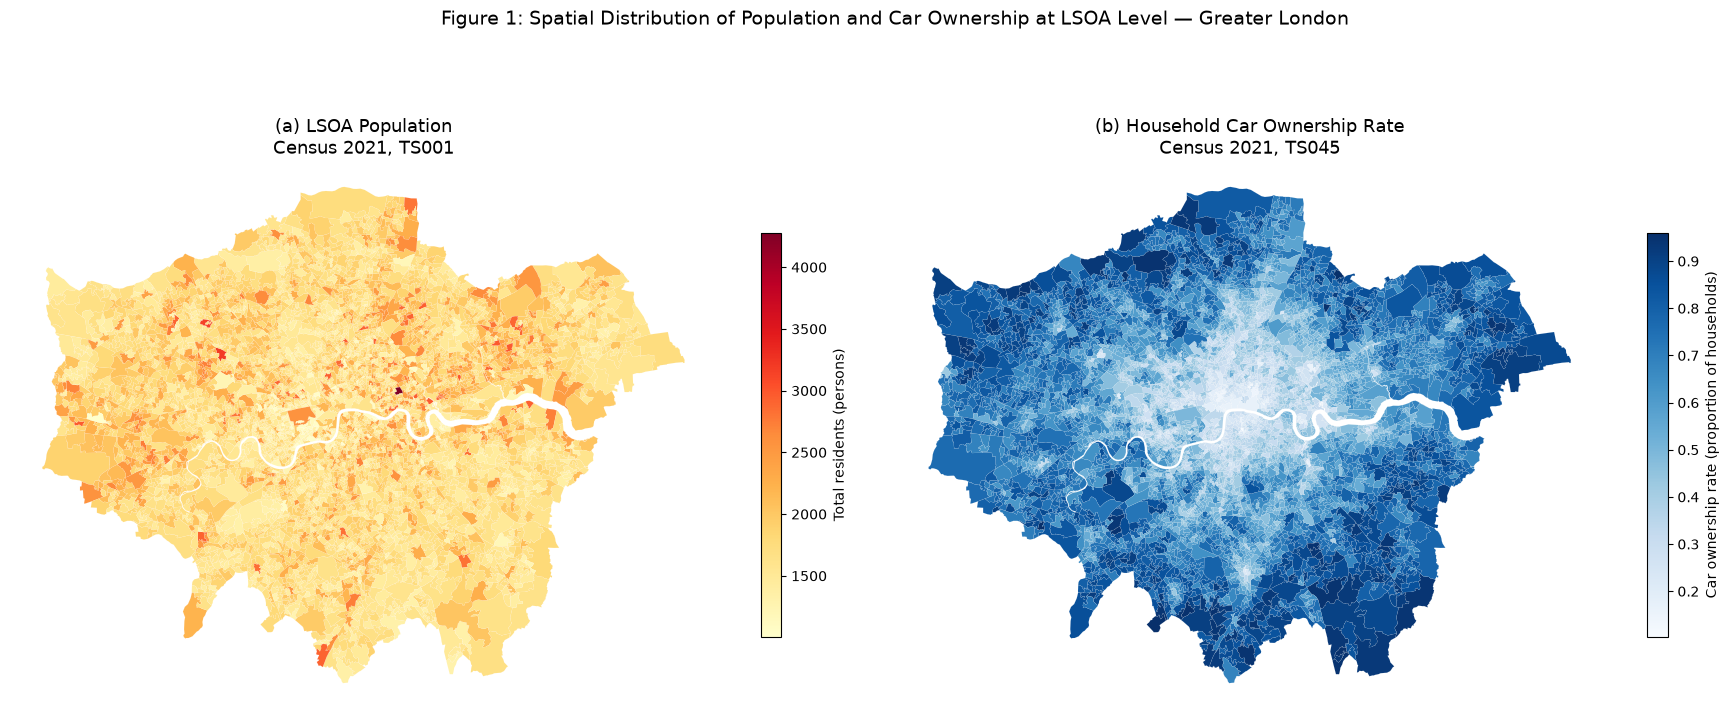

Saved: fig1_pop_car_ownership.png


In [18]:
# Filter to London LSOAs only — rows where census data was successfully merged
london = lsoa_master[lsoa_master["imd_decile"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left map: total residents from TS001
london.plot(
    column="total_residents",
    ax=axes[0],
    cmap="YlOrRd",
    legend=True,
    legend_kwds={
        "label": "Total residents (persons)",
        "shrink": 0.55,
        "orientation": "vertical"
    },
    missing_kwds={"color": "lightgrey", "label": "No data"},
    linewidth=0.05,
    edgecolor="white"
)
axes[0].set_title("(a) LSOA Population\nCensus 2021, TS001", fontsize=13)
axes[0].axis("off")

# Right map: car ownership rate from TS045
# car_ownership_rate = (total_households - cars_0) / total_households
london.plot(
    column="car_ownership_rate",
    ax=axes[1],
    cmap="Blues",
    legend=True,
    legend_kwds={
        "label": "Car ownership rate (proportion of households)",
        "shrink": 0.55,
        "orientation": "vertical"
    },
    missing_kwds={"color": "lightgrey", "label": "No data"},
    linewidth=0.05,
    edgecolor="white"
)
axes[1].set_title("(b) Household Car Ownership Rate\nCensus 2021, TS045", fontsize=13)
axes[1].axis("off")

fig.suptitle(
    "Figure 1: Spatial Distribution of Population and Car Ownership at LSOA Level — Greater London",
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig1_pop_car_ownership.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig1_pop_car_ownership.png")

### IMD 2019 Spatial Distribution

#### A choropleth map of IMD 2019 deprivation deciles at LSOA level. Decile 1 = most deprived (red), Decile 10 = least deprived (green). This map is the spatial equity baseline for the dissertation — it shows the heterogeneous deprivation pattern that Section 4 will test against EVSE coverage. The 181 imputed LSOAs (new 2021 boundaries filled with borough median) are flagged in a note on the map.

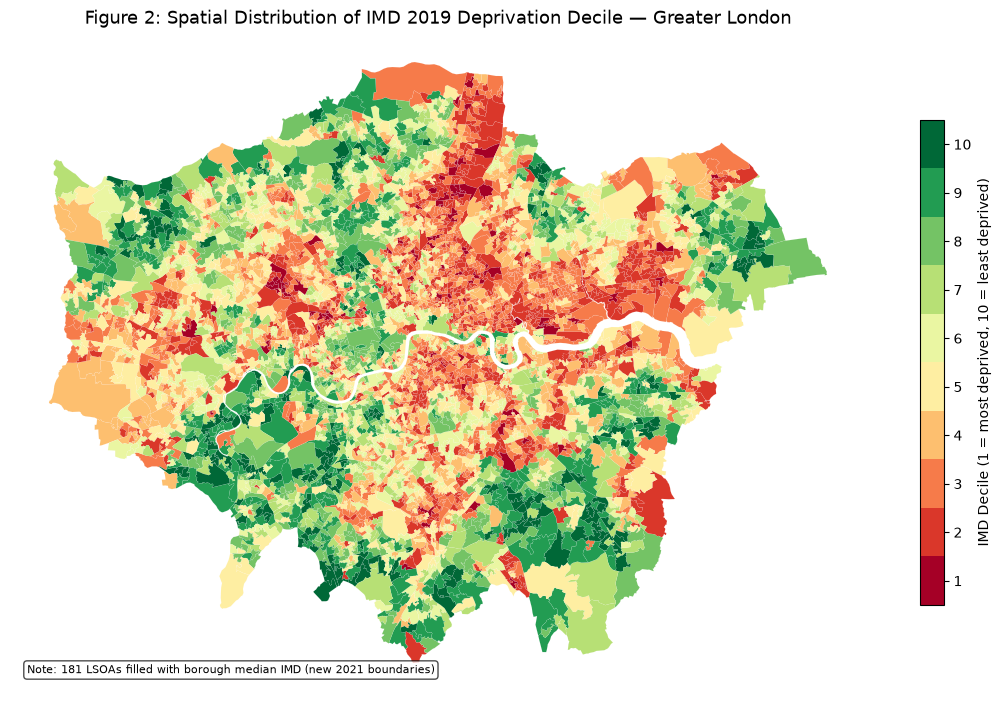

Saved: fig2_imd_distribution.png


In [19]:
# IMD decile choropleth — 10 discrete colour bands matching deciles 1 to 10
cmap_imd = plt.get_cmap("RdYlGn", 10)

fig, ax = plt.subplots(figsize=(11, 10))

london.plot(
    column="imd_decile",
    ax=ax,
    cmap=cmap_imd,
    vmin=0.5,    # shift so decile 1 gets the first full colour band
    vmax=10.5,
    legend=True,
    legend_kwds={
        "label": "IMD Decile (1 = most deprived, 10 = least deprived)",
        "shrink": 0.5,
        "ticks": list(range(1, 11))
    },
    missing_kwds={"color": "lightgrey", "label": "No data"},
    linewidth=0.05,
    edgecolor="white"
)

# Annotate the number of borough-median-imputed LSOAs
n_imputed = int(london["imd_imputed"].sum())
ax.text(
    0.02, 0.03,
    f"Note: {n_imputed} LSOAs filled with borough median IMD (new 2021 boundaries)",
    transform=ax.transAxes, fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7)
)

ax.set_title(
    "Figure 2: Spatial Distribution of IMD 2019 Deprivation Decile — Greater London",
    fontsize=13
)
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig2_imd_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig2_imd_distribution.png")

### Existing EVSE Spatial Distribution

#### Left: each dot is one charging location from osev_london_clean.csv, coloured by location_type (On-street vs Destination). The clustering pattern — dense in inner London, sparse in outer boroughs — is the first spatial evidence motivating the dissertation. Right: a horizontal bar chart showing how many locations fall into each location_category, giving a sense of the charger mix across venue types.

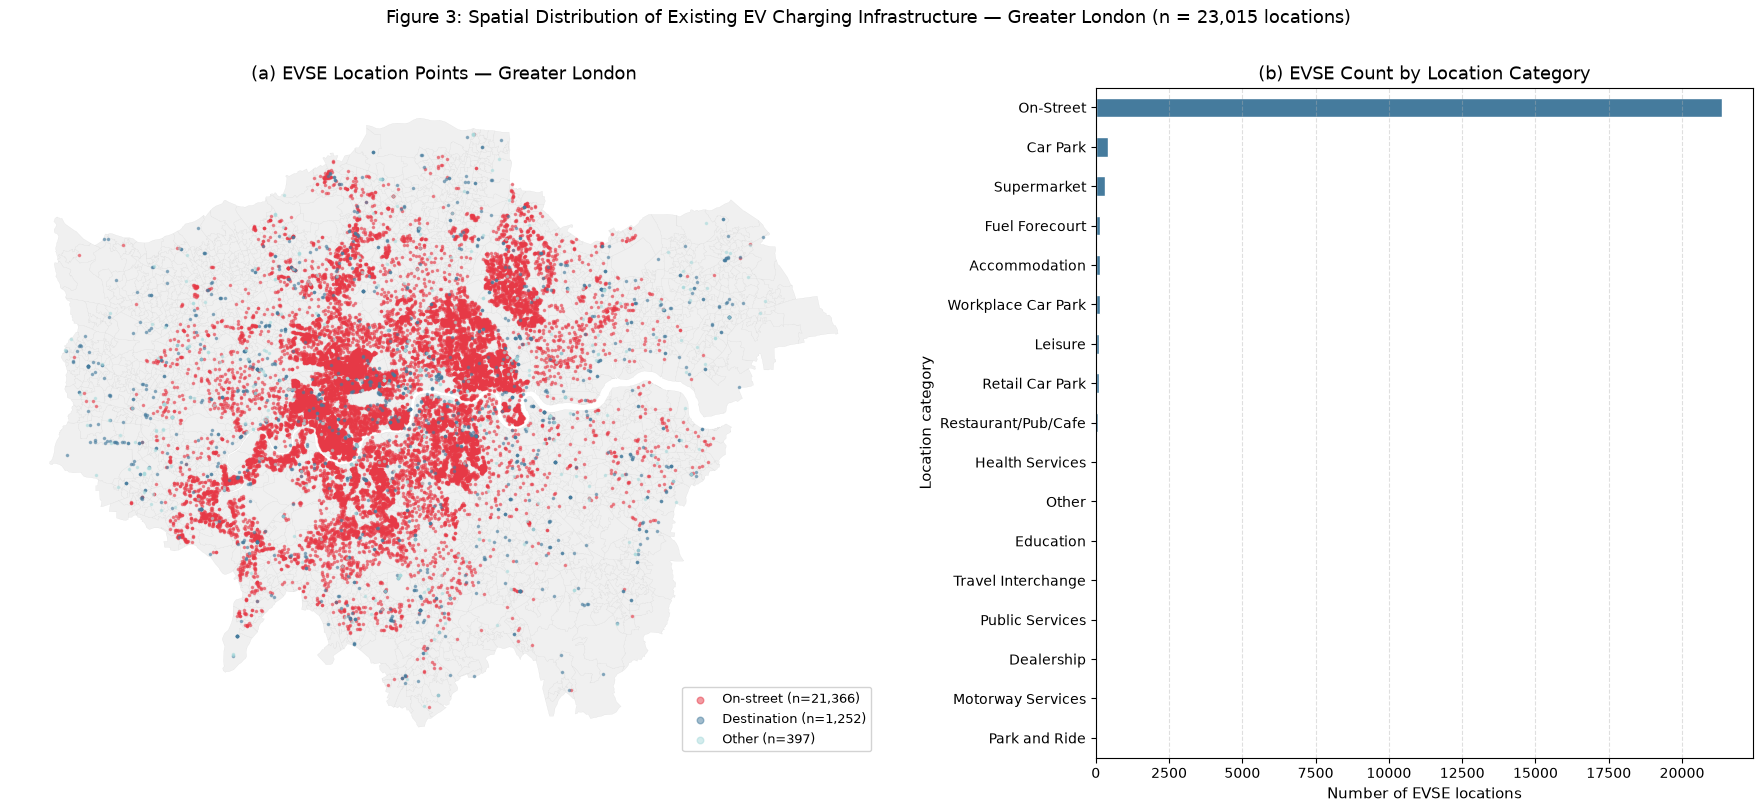

Saved: fig3_evse_distribution.png


In [20]:
fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(18, 8),
                                      gridspec_kw={"width_ratios": [1.4, 1]})

# LSOA base layer in light grey
london.plot(ax=ax_map, color="#f0f0f0", edgecolor="#cccccc", linewidth=0.1)

# Plot EVSE points coloured by location_type
type_colours = {"On-street": "#e63946", "Destination": "#457b9d"}
for loc_type, colour in type_colours.items():
    subset = evse_gdf[evse_gdf["location_type"] == loc_type]
    if len(subset) > 0:
        subset.plot(
            ax=ax_map,
            color=colour,
            markersize=2.5,
            alpha=0.5,
            label=f"{loc_type} (n={len(subset):,})"
        )

# Plot any location_types not covered by the two main categories
other = evse_gdf[~evse_gdf["location_type"].isin(type_colours.keys())]
if len(other) > 0:
    other.plot(
        ax=ax_map,
        color="#a8dadc",
        markersize=2.5,
        alpha=0.5,
        label=f"Other (n={len(other):,})"
    )

ax_map.set_title("(a) EVSE Location Points — Greater London", fontsize=13)
ax_map.axis("off")
ax_map.legend(loc="lower right", fontsize=9, framealpha=0.85, markerscale=3)

# Right panel: count by location_category sorted ascending for readability
cat_counts = osev["location_category"].value_counts().sort_values(ascending=True)
cat_counts.plot(kind="barh", ax=ax_bar, color="#457b9d", edgecolor="white")
ax_bar.set_xlabel("Number of EVSE locations", fontsize=11)
ax_bar.set_ylabel("Location category", fontsize=11)
ax_bar.set_title("(b) EVSE Count by Location Category", fontsize=13)
ax_bar.grid(axis="x", linestyle="--", alpha=0.4)

fig.suptitle(
    f"Figure 3: Spatial Distribution of Existing EV Charging Infrastructure"
    f" — Greater London (n = {len(evse_gdf):,} locations)",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig3_evse_distribution.png"), dpi=200, bbox_inches="tight")
plt.show()
print("Saved: fig3_evse_distribution.png")

### EVSE Density vs IMD Decile

The central empirical motivation figure. Left subplot: bar chart of mean EVSE density per IMD decile with ±1 SD error bars, Pearson r annotated. Right subplot: LSOA-level scatter plot with OLS trend line. If the slope is positive — more chargers per km² in wealthier deciles — this is direct empirical evidence of spatial inequity, justifying the equity constraint in location-allocation model.

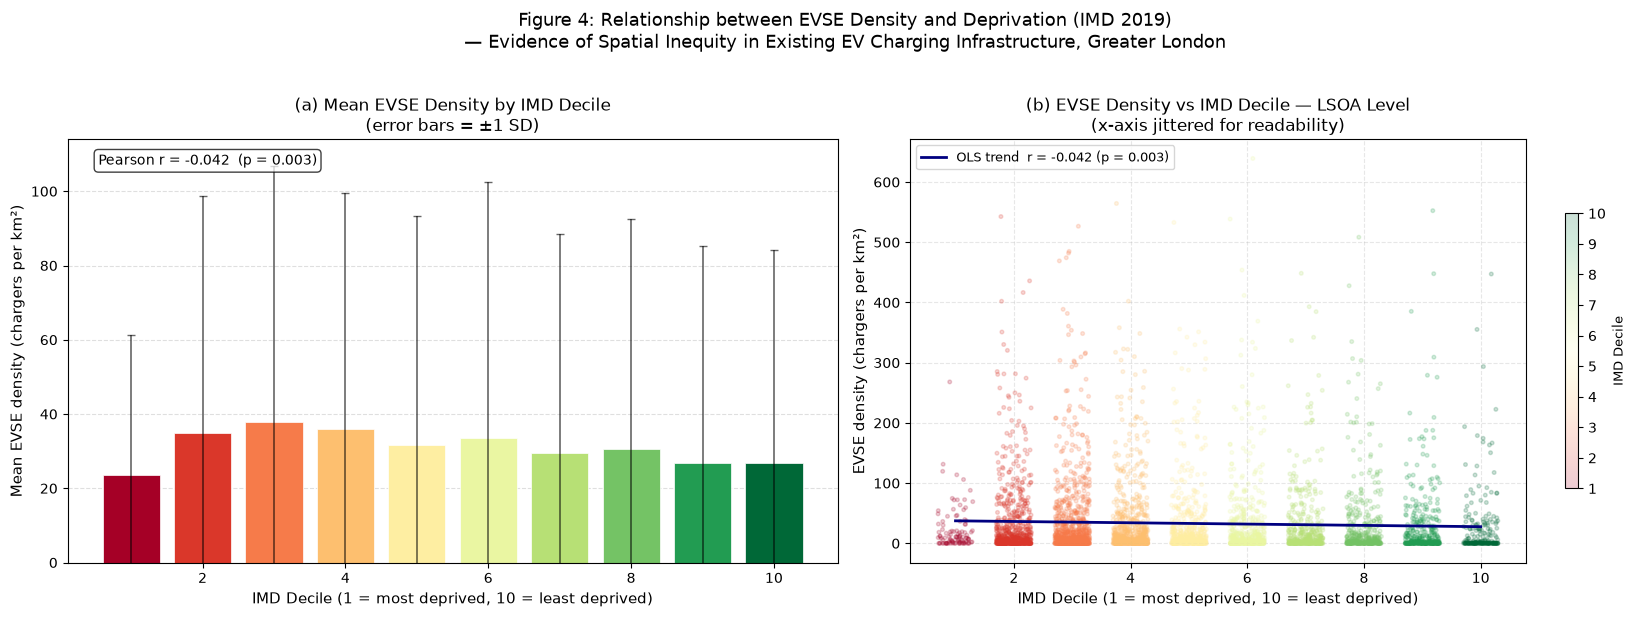

Saved: fig4_evse_density_vs_imd.png

Summary table — EVSE density by IMD decile:
 imd_decile  mean_density  std_density   n
          1     23.683542    37.570564 104
          2     34.797188    63.972810 692
          3     37.727864    69.158560 881
          4     36.053897    63.383276 690
          5     31.536115    61.666167 587
          6     33.517958    69.074241 540
          7     29.613395    58.800777 459
          8     30.690337    61.922537 416
          9     26.906369    58.462764 407
         10     26.798373    57.254461 218


In [22]:
# Drop rows with missing imd_decile or evse_density
valid = london.dropna(subset=["imd_decile", "evse_density"]).copy()
valid["imd_decile"] = valid["imd_decile"].astype(int)

# Aggregate mean and SD of EVSE density per IMD decile
decile_stats = (
    valid.groupby("imd_decile")["evse_density"]
    .agg(mean_density="mean", std_density="std", n="count")
    .reset_index()
)

# Pearson correlation at LSOA level
r_val, p_val = pearsonr(valid["imd_decile"], valid["evse_density"])
p_label = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"

# OLS coefficients for trend line
m, b = np.polyfit(valid["imd_decile"], valid["evse_density"], 1)

# Discrete colour palette: red (decile 1) to green (decile 10)
bar_colours = [plt.get_cmap("RdYlGn", 10)(i / 9) for i in range(10)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

# Left subplot: bar chart with SD error bars
ax1.bar(
    decile_stats["imd_decile"],
    decile_stats["mean_density"],
    yerr=decile_stats["std_density"],
    color=bar_colours,
    edgecolor="white",
    linewidth=0.5,
    error_kw={"elinewidth": 1.2, "capsize": 3, "alpha": 0.6},
    zorder=2
)
ax1.set_xlabel("IMD Decile (1 = most deprived, 10 = least deprived)", fontsize=11)
ax1.set_ylabel("Mean EVSE density (chargers per km²)", fontsize=11)
# Add this line after ax1.grid(...) in Section 4
ax1.set_ylim(bottom=0)
ax1.set_title("(a) Mean EVSE Density by IMD Decile\n(error bars = ±1 SD)", fontsize=12)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.grid(axis="y", linestyle="--", alpha=0.4, zorder=1)
ax1.text(
    0.04, 0.94,
    f"Pearson r = {r_val:.3f}  ({p_label})",
    transform=ax1.transAxes, fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.75)
)

# Right subplot: LSOA-level scatter with jitter and OLS trend line
np.random.seed(42)
sc = ax2.scatter(
    valid["imd_decile"] + np.random.uniform(-0.3, 0.3, len(valid)),
    valid["evse_density"],
    c=valid["imd_decile"],
    cmap="RdYlGn",
    vmin=1, vmax=10,
    alpha=0.20,
    s=7,
    zorder=2
)

# OLS trend line
x_line = np.linspace(1, 10, 200)
ax2.plot(
    x_line, m * x_line + b,
    color="navy", linewidth=2, zorder=3,
    label=f"OLS trend  r = {r_val:.3f} ({p_label})"
)
ax2.set_xlabel("IMD Decile (1 = most deprived, 10 = least deprived)", fontsize=11)
ax2.set_ylabel("EVSE density (chargers per km²)", fontsize=11)
ax2.set_title("(b) EVSE Density vs IMD Decile — LSOA Level\n(x-axis jittered for readability)", fontsize=12)
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
ax2.legend(fontsize=9, loc="upper left")
ax2.grid(linestyle="--", alpha=0.3, zorder=1)
cbar = plt.colorbar(sc, ax=ax2, shrink=0.65)
cbar.set_label("IMD Decile", fontsize=9)

fig.suptitle(
    "Figure 4: Relationship between EVSE Density and Deprivation (IMD 2019)\n"
    "— Evidence of Spatial Inequity in Existing EV Charging Infrastructure, Greater London",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig4_evse_density_vs_imd.png"), dpi=200, bbox_inches="tight")
plt.show()

print("Saved: fig4_evse_density_vs_imd.png")
print()
print("Summary table — EVSE density by IMD decile:")
print(decile_stats.to_string(index=False))

The negative r = -0.042 (p = 0.003) shows that more deprived LSOAs actually have slightly higher charger density per km². This is explained by London's urban structure: deprived LSOAs concentrate in inner London where areas are small and on-street chargers are densely packed. However, density per km² is not the right equity metric — it ignores population size and demand. This result strengthens your argument: a demand-weighted location-allocation model is needed to properly capture spatial equity.